### **PROFIT-AWARE & EXPLAINABLE CUSTOMER CHURN PREDICTION USING COST-SENSITIVE LEARNING**

In [ ]:
from google.colab import files
data = files.upload()

Saving BankChurners.csv to BankChurners.csv



DATASET LOADED: 10127 rows × 23 columns

>>> ORIGINAL DATASET INFO <<<
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender   

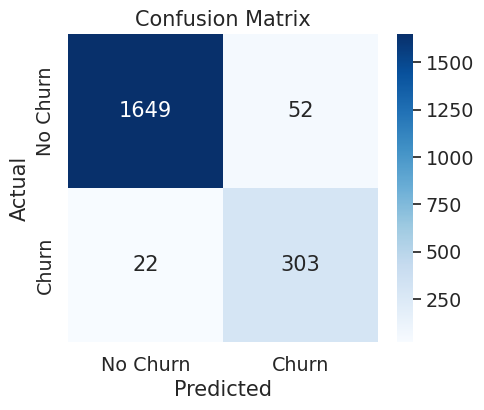

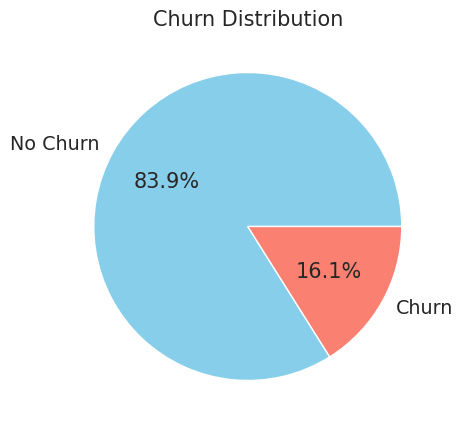

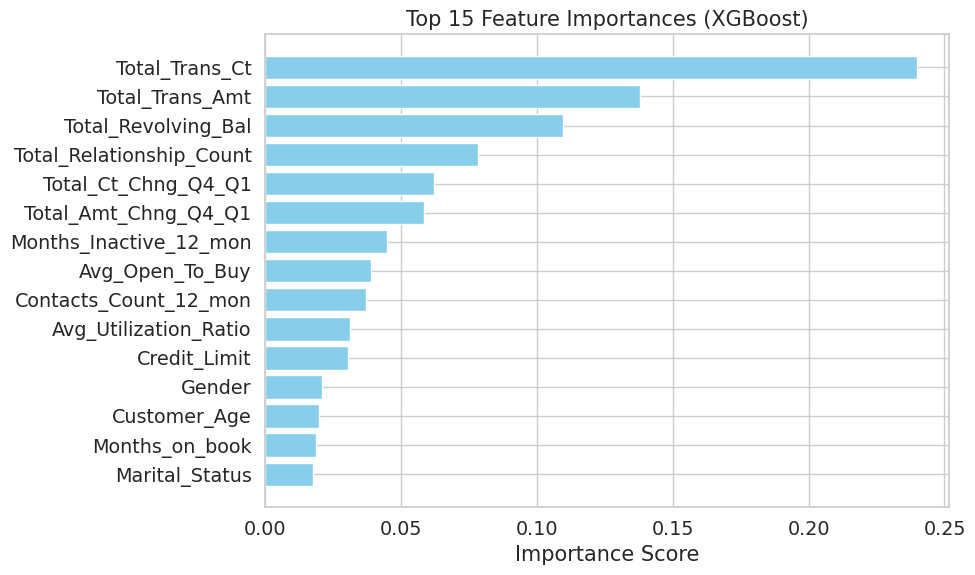

PermutationExplainer explainer: 201it [01:43,  1.83it/s]


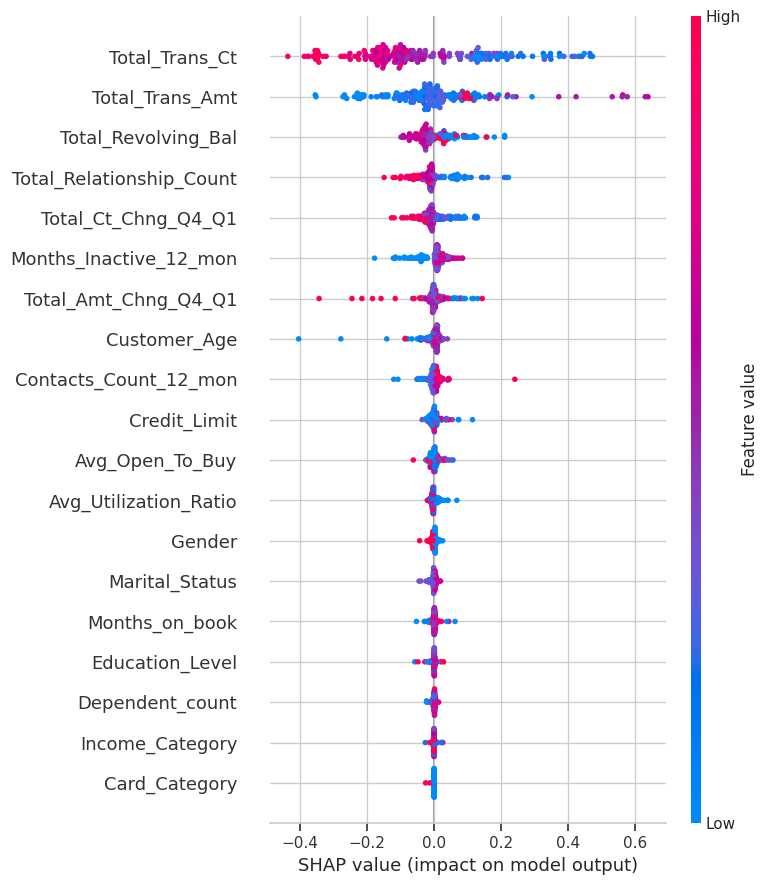

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)
from xgboost import XGBClassifier
import shap
import warnings


# Warnings & Visual Style
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style="whitegrid", palette="bright", font_scale=1.25)


# 1. Load Dataset
df = pd.read_csv("BankChurners.csv")
print("\n" + "="*70)
print(f"DATASET LOADED: {df.shape[0]} rows × {df.shape[1]} columns")
print("="*70 + "\n")


# 2. Dataset Overview
print(">>> ORIGINAL DATASET INFO <<<")
print(df.info())
print("\n" + "-"*70 + "\n")
print("\nMissing Values Per Column:")
print(df.isnull().sum())
print("\n" + "-"*70 + "\n")
print("\nTarget Class Distribution:")
print(df['Attrition_Flag'].value_counts(normalize=True).rename("Proportion") * 100)
print("\n" + "="*70 + "\n")


# 3. Data Preprocessing
drop_cols = [col for col in df.columns if 'Naive_Bayes' in col]
df.drop(columns=drop_cols, inplace=True)

df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
}).astype(int)

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=['Attrition_Flag', 'CLIENTNUM'])
y = df['Attrition_Flag']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(">> DATASET INFO AFTER PREPROCESSING <<")
print(df.info())
print("\n" + "-"*70 + "\n")

print("\n" + "="*70 + "\n")


# 4. Handle Class Imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print(f">> CLASS IMBALANCE CHECK <<")
print(f"Negative samples (No Churn) : {neg}")
print(f"Positive samples (Churn)    : {pos}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")
print("="*70 + "\n")

rng = np.random.default_rng(42)
clv = rng.uniform(1000, 10000, size=len(y_train))
sample_weights = np.where(y_train == 1, clv * scale_pos_weight, clv)


# 5. Model Training
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.05,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train, sample_weight=sample_weights)


# 6. Model Evaluation

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

print(">>> MODEL PERFORMANCE <<<")
for k, v in metrics.items():
    print(f"{k:<10}: {v:.4f}")
print("="*70 + "\n")

print(">>> CLASSIFICATION REPORT <<<")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print("="*70 + "\n")


# 7. Business Insights
print(">>> BUSINESS INSIGHTS <<<")
print(f"- Recall: {metrics['Recall']:.2%} of potential churners correctly identified.")
print(f"- Precision: {metrics['Precision']:.2%}, minimizing false alarms and optimizing retention budget.")
print(f"- ROC-AUC: {metrics['ROC AUC']:.2f}, strong discrimination between churners and non-churners.")
print("="*70 + "\n")


# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("\n" + "="*70 + "\n")


# 9. Churn Distribution (Pie Chart)
plt.figure(figsize=(5, 5))
plt.pie(df['Attrition_Flag'].value_counts(),
        labels=['No Churn', 'Churn'],
        autopct='%1.1f%%',
        colors=['skyblue', 'salmon'])
plt.title("Churn Distribution")
plt.show()
print("\n" + "="*70 + "\n")


# 10. Feature Importance
importance = model.feature_importances_
sorted_idx = np.argsort(importance)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], importance[sorted_idx], color='skyblue')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print("\n" + "="*70 + "\n")


# 11. SHAP Explainability
rng_shap = np.random.default_rng(42)
explainer = shap.PermutationExplainer(model.predict_proba, X_train, rng=rng_shap)
shap_values = explainer(X_test[:200])

shap.summary_plot(
    shap_values.values[:, :, 1],
    features=X_test[:200],
    feature_names=X.columns
)
print("\n" + "="*70 + "\n")
